In [1]:
%pip install pillow pillow-avif-plugin

Note: you may need to restart the kernel to use updated packages.


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pillow_avif

In [3]:
print(cv2.getBuildInformation())


General configuration for OpenCV 4.9.0 =====================================
  Version control:               4.9.0

  Platform:
    Timestamp:                   2023-12-31T11:21:12Z
    Host:                        Windows 10.0.17763 AMD64
    CMake:                       3.24.2
    CMake generator:             Visual Studio 14 2015
    CMake build tool:            MSBuild.exe
    MSVC:                        1900
    Configuration:               Debug Release

  CPU/HW features:
    Baseline:                    SSE SSE2 SSE3
      requested:                 SSE3
    Dispatched code generation:  SSE4_1 SSE4_2 FP16 AVX AVX2
      requested:                 SSE4_1 SSE4_2 AVX FP16 AVX2 AVX512_SKX
      SSE4_1 (16 files):         + SSSE3 SSE4_1
      SSE4_2 (1 files):          + SSSE3 SSE4_1 POPCNT SSE4_2
      FP16 (0 files):            + SSSE3 SSE4_1 POPCNT SSE4_2 FP16 AVX
      AVX (8 files):             + SSSE3 SSE4_1 POPCNT SSE4_2 AVX
      AVX2 (36 files):           + SSSE3 SSE4_1 

In [4]:
image = cv2.imread("receipt 2.webp")
cv2.imshow("Can we?", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [6]:
pil_image = Image.open("credit card.avif")
receipt = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
cv2.imshow("Can we?", receipt)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [3]:
def show(image):
    plt.imshow(image[:, :, ::-1])
    plt.show()

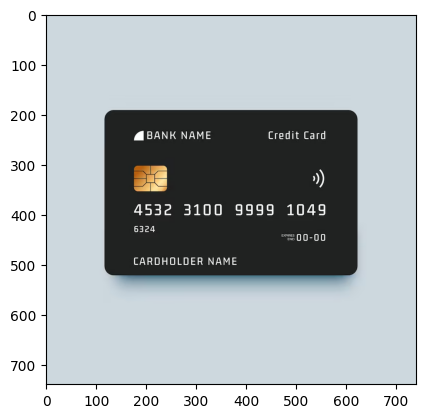

In [8]:
creditcard = Image.open("credit card.avif")
creditcard = cv2.cvtColor(np.array(creditcard), cv2.COLOR_RGB2BGR)
show(creditcard)

In [ ]:
src_pts = np.float32([
    [110, 198],
    [610, 198],
    [110, 515],
    [610, 515]
])

width, height = 450, 300

dst_pts = np.float32([
    [0, 0],
    [width-1, 0],
    [0, height-1],
    [width-1, height-1]
])

In [ ]:
M = cv2.getPerspectiveTransform(src_pts, dst_pts)
M

In [ ]:
warp_creditcard = cv2.warpPerspective(creditcard, M, (width, height))
show(warp_creditcard)

In [ ]:
credit2 = cv2.imread("credit card 2.jpg")
show(credit2)

In [ ]:
src_pts = np.float32([
    [570, 220],
    [1080, 195],
    [1100, 490],
    [600, 570]
])

width, height = 450, 300

dst_pts = np.float32([
    [0, 0],
    [width-1, 0],
    [width-1, height-1],
    [0, height-1]
])

In [ ]:
M = cv2.getPerspectiveTransform(src_pts, dst_pts)
M

In [ ]:
warp_credit2 = cv2.warpPerspective(credit2, M, (width, height))
show(warp_credit2)

In [5]:
def warpImage(src, src_pts, dim):
    width, height = dim[0], dim[1]

    dst_pts = np.float32([
        [0, 0],
        [width-1, 0],
        [width-1, height-1],
        [0, height-1]
    ])

    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(src, M, dim)

    return warped

In [7]:
def readAVIF(loc):
    pil_img = Image.open(loc)
    image = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    return image

In [ ]:
receipt1 = readAVIF("recipt.avif")
show(receipt1)

In [ ]:
src_pts = np.float32([
    [87, 10],
    [280, 11],
    [280, 310],
    [88, 310]
])

w, h = 175, 300

warp_receipt1 = warpImage(receipt1, src_pts, (w, h))
show(warp_receipt1)

In [ ]:
test = np.array([[20, 20], [10, 10]], dtype = np.float32)
print(len(test))
test.resize(0)
len(test)

In [9]:
coordinates = []

def getSourcePts(event, x, y, flag, param):
    global image, coordinates
    
    if event == cv2.EVENT_LBUTTONDBLCLK:
        coordinates.append([x, y])
        cv2.circle(image, (x, y), 5, (0, 255, 0), -1)

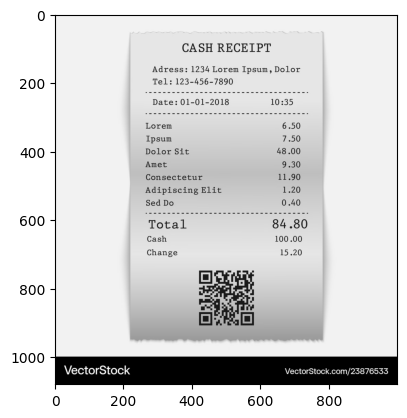

In [21]:
loc = "receipt.avif"
image = readAVIF(loc)
receipt2 = image.copy()
show(image)

Instructions: Double Click on the point of Document corners in clockwise direction starting from Top left corner
The 4 corners [[222.  55.]
 [780.  61.]
 [774. 783.]
 [219. 772.]]


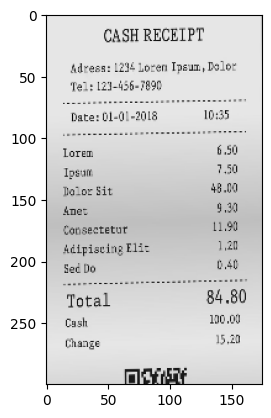

In [22]:
window_name = "Mark points for document"
cv2.namedWindow(window_name)

cv2.setMouseCallback(window_name, getSourcePts)

print("Instructions: Double Click on the point of Document corners in clockwise direction starting from Top left corner")

src_pts = coordinates.copy()
while True:
    cv2.imshow(window_name, image)
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        src_pts = np.float32(coordinates)
        print(f"The 4 corners {src_pts}")
        break
    elif key == ord('r'):
        coordinates.clear()
        image = cv2.imread(loc) if cv2.imread(loc) is not None else readAVIF(loc)

cv2.destroyAllWindows()

warp_receipt2 = warpImage(receipt2, src_pts, (175, 300))
show(warp_receipt2)

## Document Scanner and Enhancer

### By Gemini

In [25]:
import cv2
import numpy as np

def order_points(pts):
    """
    Orders 4 corner coordinates in consistent sequence:
    [top-left, top-right, bottom-right, bottom-left]
    """
    rect = np.zeros((4, 2), dtype="float32")
    
    # Top-left has the smallest sum (x+y), bottom-right has the largest sum
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    
    # Top-right has the smallest difference (y-x), bottom-left has the largest difference
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    
    return rect

def scan_document(image_path):
    # Step 1: Load image and compute resize ratio
    image = cv2.imread(image_path) if cv2.imread(image_path) is not None else readAVIF(image_path)
    if image is None:
        print("Error: Invalid image path!")
        return

    orig = image.copy()
    ratio = image.shape[0] / 500.0
    h = 500
    w = int(image.shape[1] / ratio)
    resized = cv2.resize(image, (w, h))

    # Step 2: Preprocessing (Grayscale + Blur + Canny Edges)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 75, 200)

    # Step 3: Find Contours and locate largest 4-sided polygon
    contours, _ = cv2.findContours(edged, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

    doc_cnt = None
    for c in contours:
        perimeter = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * perimeter, True)

        # Document contour found if polygon has 4 vertices
        if len(approx) == 4:
            doc_cnt = approx
            break

    if doc_cnt is None:
        print("Could not find a 4-sided document contour!")
        return

    # Draw detected green contour on preview frame
    cv2.drawContours(resized, [doc_cnt], -1, (0, 255, 0), 2)

    # Step 4: Scale coordinates back to original high-res image
    pts = doc_cnt.reshape(4, 2) * ratio
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # Calculate width of new image (max distance between top and bottom corners)
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    # Calculate height of new image (max distance between left and right corners)
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))

    # Construct destination coordinates
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")

    # Step 5: Perspective Warp
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(orig, M, (maxWidth, maxHeight))

    # Step 6: Apply Adaptive Thresholding for B&W "Scanned" Effect
    warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    scanned = cv2.adaptiveThreshold(
        warped_gray, 255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 21, 10
    )

    # Save and Display Output
    cv2.imshow("Original with Outline", resized)
    cv2.imshow("Scanned Document", scanned)
    cv2.imwrite("scanned_output.png", scanned)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# Run project
scan_document("receipt 3.jpg")

Could not find a 4-sided document contour!


In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [13]:
coordinates = []

def getSourcePts(event, x, y, flag, param):
    if event == cv2.EVENT_LBUTTONDBLCLK:
        coordinates.append([x, y])
        cv2.circle(image, (x, y), 5, (0, 255, 0), -1)

In [15]:
def show(image):
    plt.imshow(image[:, :, ::-1])
    plt.show()

In [17]:
def warpImage(src, src_pts, dim):
    width, height = dim[0], dim[1]

    dst_pts = np.float32([
        [0, 0],
        [width-1, 0],
        [width-1, height-1],
        [0, height-1]
    ])

    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(src, M, dim)

    return warped

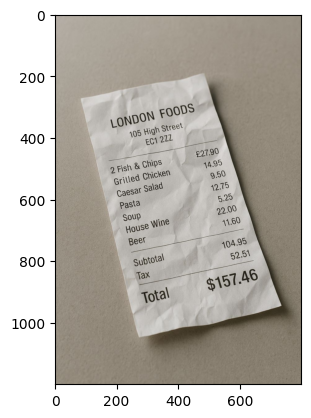

In [30]:
test = cv2.imread("receipt 3.jpg")
show(test)

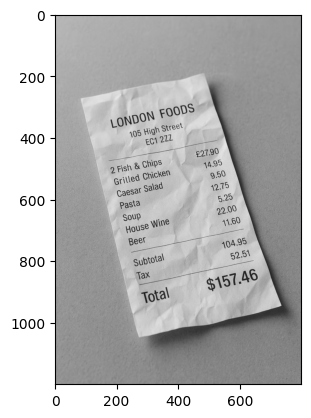

In [31]:
test_gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)
plt.imshow(test_gray, cmap = 'gray')

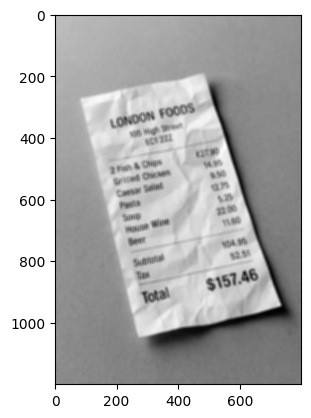

In [32]:
blur = cv2.GaussianBlur(test_gray, (11, 11), 10)
plt.imshow(blur, cmap = 'gray')

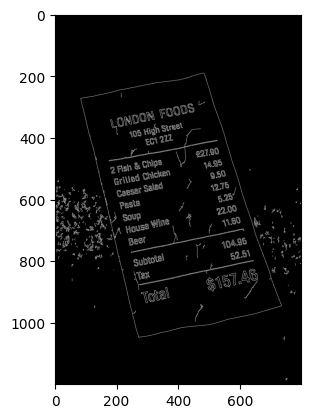

In [33]:
blur = cv2.Canny(test_gray, 50, 150)
plt.imshow(blur, cmap = 'gray')

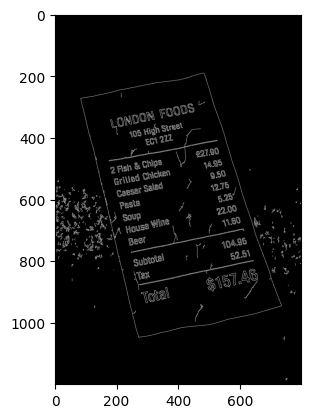

In [34]:
_, thresh_test = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(thresh_test, cmap = "gray")

2


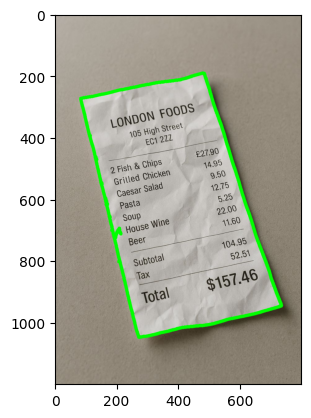

In [35]:
contours, hierarchy = cv2.findContours(thresh_test, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
w, h = test.shape[:2]
test_area = w*h
valid = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > (0.3 * test_area):
        valid.append(cnt)
        

print(len(valid))
copy1 = test.copy()
cv2.drawContours(copy1, valid, -1, (0, 255, 0), 10)
show(copy1)

[[[ 480  191]]

 [[  83  274]]

 [[ 271 1048]]

 [[ 733  946]]]
[[[ 480  191]]

 [[ 733  945]]

 [[ 272 1048]]

 [[  83  275]]]
2


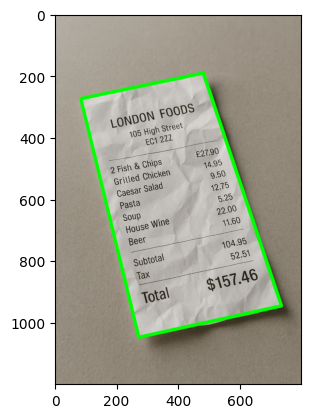

In [36]:
contours, hierarchy = cv2.findContours(thresh_test, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
w, h = test.shape[:2]
test_area = w*h
valid = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > (0.3 * test_area):
        perimeter = cv2.arcLength(cnt, True)

        epsilon = 0.03 * perimeter
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        print(approx)
        valid.append(approx)
        

print(len(valid))
copy2 = test.copy()
cv2.drawContours(copy2, valid, 0, (0, 255, 0), 10)
show(copy2)

In [37]:
valid = np.array(valid)
print(valid)
src_pts = valid.reshape((8, 2))[:4]
pts = np.float32(src_pts)
pts

[[[[ 480  191]]

  [[  83  274]]

  [[ 271 1048]]

  [[ 733  946]]]


 [[[ 480  191]]

  [[ 733  945]]

  [[ 272 1048]]

  [[  83  275]]]]


array([[ 480.,  191.],
       [  83.,  274.],
       [ 271., 1048.],
       [ 733.,  946.]], dtype=float32)

In [19]:
def createSrcPts(pts):
    pts = np.array(pts)
    pts = pts.ravel()[:8]
    pts = pts.reshape((4,2))
    
    src_pts = []
    bl, br, tl, tr = 2**31-1, -2**31, 2**31 - 1, -2**31
    bll, brl, tll, trl = [], [], [], []
    
    for i in pts:
        x, y = i[0], i[1]
        if tl > x + y:
            tl = x+y
            tll = [x, y]
        if br < x + y:
            br = x + y
            brl = [x, y]
        if bl > x - y:
            bl = x - y
            bll = [x, y]
        if tr < x - y:
            tr = x - y
            trl = [x, y]

    src_pts.extend([tll, trl, brl, bll])

    return src_pts

In [39]:
src_pts = np.float32(createSrcPts(valid))
src_pts

array([[  83.,  274.],
       [ 480.,  191.],
       [ 733.,  946.],
       [ 271., 1048.]], dtype=float32)

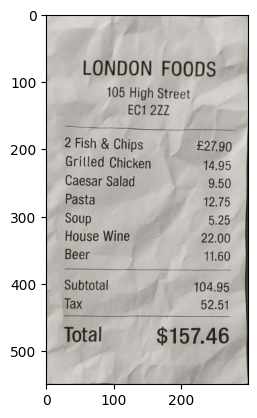

In [40]:
warped = warpImage(test, src_pts, (300, 550))
show(warped)

# Document Scanner and Enhancer (Manual and Automatic)

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pillow_avif

In [7]:
def readAVIF(loc):
    pil_img = Image.open(loc)
    image = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    return image

In [13]:
coordinates = []

def getSourcePts(event, x, y, flag, param):
    if event == cv2.EVENT_LBUTTONDBLCLK:
        coordinates.append([x, y])
        cv2.circle(image, (x, y), 5, (0, 255, 0), -1)

In [15]:
def show(image):
    plt.imshow(image[:, :, ::-1])
    plt.show()

In [17]:
def warpImage(src, src_pts, dim):
    width, height = dim[0], dim[1]

    dst_pts = np.float32([
        [0, 0],
        [width-1, 0],
        [width-1, height-1],
        [0, height-1]
    ])

    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(src, M, dim)

    return warped

In [19]:
def createSrcPts(pts):
    pts = np.array(pts)
    pts = pts.ravel()[:8]
    pts = pts.reshape((4,2))
    
    src_pts = []
    bl, br, tl, tr = 2**31-1, -2**31, 2**31 - 1, -2**31
    bll, brl, tll, trl = [], [], [], []
    
    for i in pts:
        x, y = i[0], i[1]
        if tl > x + y:
            tl = x+y
            tll = [x, y]
        if br < x + y:
            br = x + y
            brl = [x, y]
        if bl > x - y:
            bl = x - y
            bll = [x, y]
        if tr < x - y:
            tr = x - y
            trl = [x, y]

    src_pts.extend([tll, trl, brl, bll])

    return src_pts

In [23]:
def show_image(image, title="Image", max_width=1200, max_height=800):
    h, w = image.shape[:2]

    scale = min(max_width / w, max_height / h, 1)

    display = cv2.resize(
        image,
        (int(w * scale), int(h * scale))
    )

    cv2.imshow(title, display)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [39]:
def manualScanDocument(location):
    global image
    img = cv2.imread(location) if cv2.imread(location) is not None else readAVIF(location)
    if img is None:
        print("Error! Invalid Location for image")

    ratio = img.shape[0] / 500.0
    h = 500
    w = int(img.shape[1] / ratio)
    image = cv2.resize(img, (w, h))
    org = image.copy()

    window_name = "Mark the corners of Document"
    cv2.namedWindow(window_name)
    cv2.setMouseCallback(window_name, getSourcePts)

    src_pts = coordinates.copy()
    while True:
        cv2.imshow(window_name, image)
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            src_pts = createSrcPts(coordinates)
            coordinates.clear()
            break
        elif key == ord('r'):
            coordinates.clear()
            img = cv2.imread(loc) if cv2.imread(loc) is not None else readAVIF(loc)
            ratio = img.shape[0] / 500.0
            h = 500
            w = int(img.shape[1] / ratio)
            image = cv2.resize(img, (w, h))
    
    cv2.destroyAllWindows()
    src_pts = np.float32(src_pts)
    if len(src_pts) == 4:
        warped = warpImage(org, src_pts, (175, 300))
        warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
        scanned = cv2.adaptiveThreshold(
            warped_gray, 255, 
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY, 21, 10
        )
        show_image(scanned, title="Scanned Document")
    else:
        print("All 4 coordinates are not selected")

In [44]:
loc = "receipt 3.jpg"
#image = cv2.imread("coins 2.jpg")
manualScanDocument(loc)

In [58]:
def autoScanDocument(location):
    image = cv2.imread(location) if cv2.imread(location) is not None else readAVIF(location)
    show_image(image)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 1)
    canny = cv2.Canny(blur, 50, 150)

    kernel = np.ones((5,5), np.uint8)
    closed = cv2.dilate(canny, kernel, iterations = 2)
    closed = cv2.erode(closed, kernel, iterations = 1)

    contours,_ = cv2.findContours(closed, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    h, w = image.shape[:2]
    img_area = w*h
    valid = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > (0.2 * img_area):
            perimeter = cv2.arcLength(cnt, True)
            epsilon = 0.03 * perimeter
            approx = cv2.approxPolyDP(cnt, epsilon, True)
            if len(approx) == 4:
                valid.append(approx)
    src_pts = np.float32(createSrcPts(valid))
    warped = warpImage(image, src_pts, (175, 300))
    warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    scanned = cv2.adaptiveThreshold(
        warped_gray, 255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 21, 10
    )
    show_image(scanned, title="Scanned Document")

In [60]:
loc = "receipt 3.jpg"
autoScanDocument(loc)

In [62]:
def scanDocument(location):
    image = cv2.imread(location) if cv2.imread(location) is not None else readAVIF(location)
    cv2.imshow("Document", image)
    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == ord('a'):
            autoScanDocument(location)
            break
        elif key == ord('m'):
            manualScanDocument(location)
            break
        elif key == ord('q'):
            break
    cv2.destroyAllWindows()

In [64]:
scanDocument(loc)